In [257]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [258]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA


In [259]:
df.shape

(1338, 7)

In [260]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [261]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [262]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [263]:
# we can use .sum .count
df.isna().any()

age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool

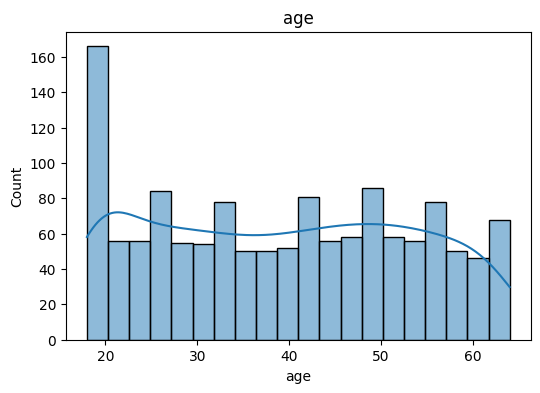

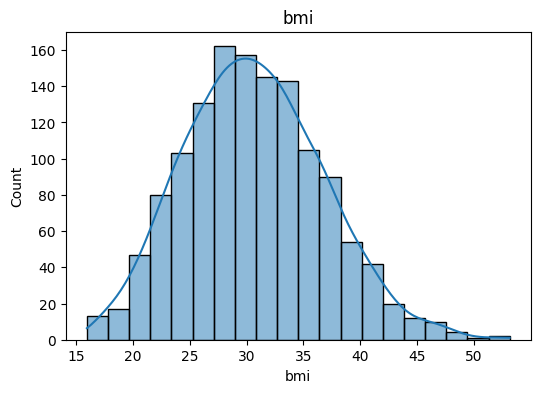

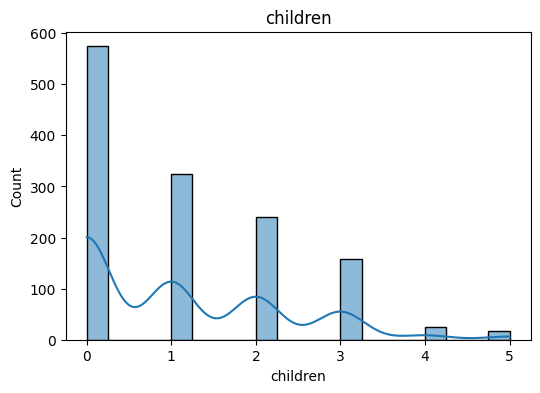

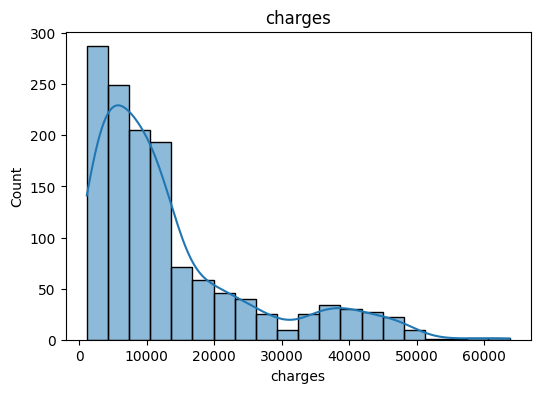

In [264]:
# we need to visually analyze our data colm which are integers
numeric_cols = ["age","bmi","children","charges"]
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True,bins=20)
    plt.title(col)

<Axes: xlabel='sex', ylabel='count'>

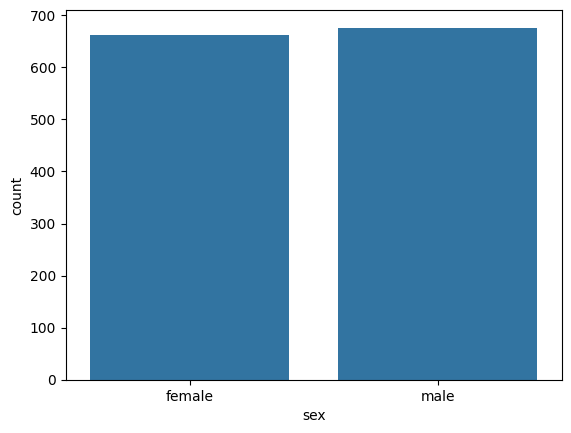

In [265]:
sns.countplot(x=df["sex"])

<Axes: xlabel='smoker', ylabel='count'>

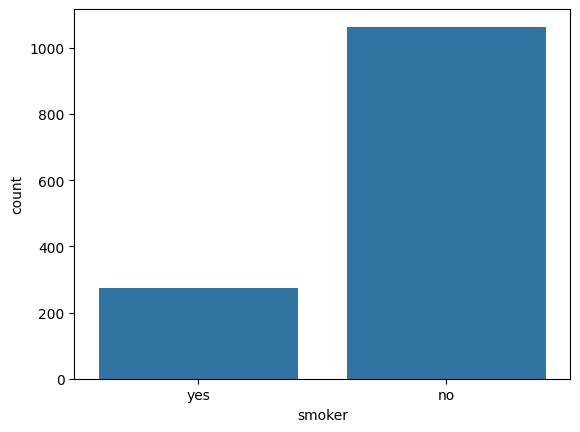

In [266]:
sns.countplot(x=df["smoker"])

<Axes: xlabel='region', ylabel='count'>

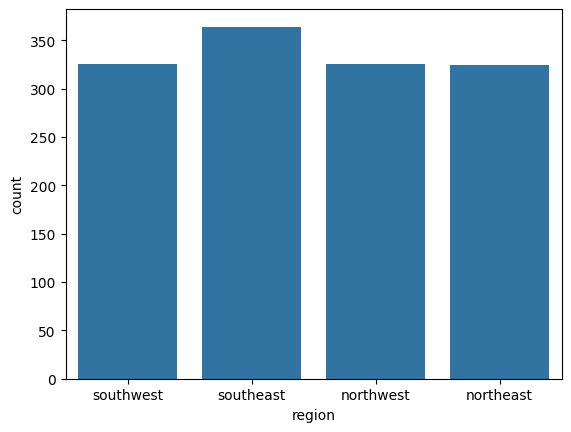

In [267]:
sns.countplot(x=df["region"])

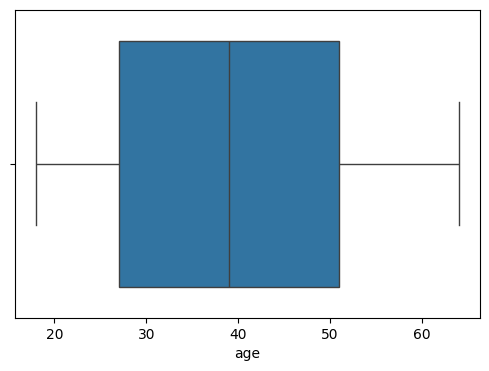

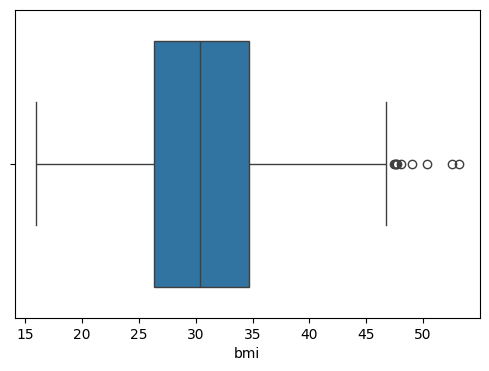

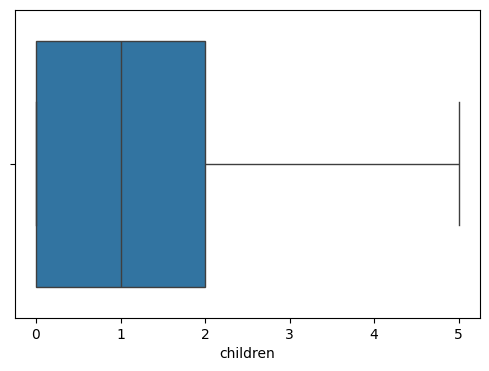

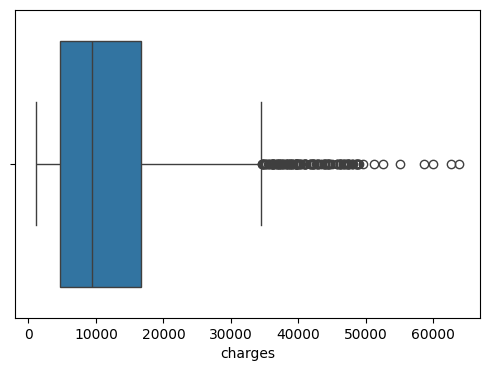

In [268]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

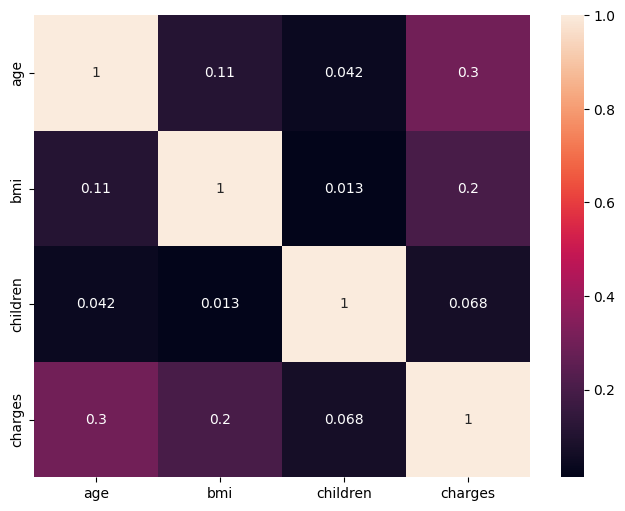

In [269]:
# we should also check coorealtion bw all numeric cols
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

## DATA CLEANING AND PROCESSING

In [270]:
# here we remove null values or add new values in them or remove outliers or remove rows with duplicate values
# and we can also convert cols string values into int because machine canncot understand str
df_cleaned = df.copy()
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [271]:
# before there were 1338 rows
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [272]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [273]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [274]:
# now we need to convert these str into ints an somethimes there can me Male or male so they both will be 
# treated as different values i order to check 

df_cleaned["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [275]:
df_cleaned["sex"] = df_cleaned["sex"].map({"male": 0, "female": 1})

In [276]:

df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [277]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [278]:
df_cleaned["smoker"] = df_cleaned["smoker"].map({"no": 0, "yes": 1})

In [279]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [280]:
df_cleaned.rename(columns={"sex": "is_female", "smoker": "is_smoker"},inplace=True)

In [281]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [282]:
# we can see here are 4 values so 0 1 2 3 are not good so we will use 1 hot encoding making new columns for each
df_cleaned["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [283]:
df_cleaned = pd.get_dummies(df_cleaned,columns=["region"])


In [284]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [285]:
df_cleaned = df_cleaned.astype(int)

In [286]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


## FEATURE ENGINEERING AND EXTRACTION

<Axes: xlabel='bmi', ylabel='Count'>

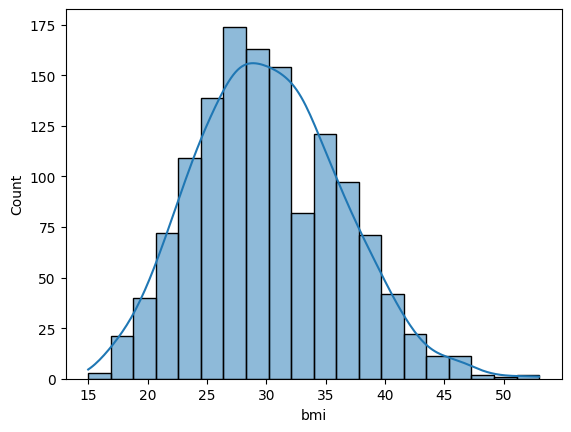

In [291]:
# here what we do is we create new columns and check if our model is predicting well and then we remove those cols
# and check if its prediction good and use the one which is giving better prediction results

sns.histplot(x=df_cleaned["bmi"],bins=20,kde=True)

In [295]:
# now we can create a new colm and based on bmi we can tell if person is overweight underweight etc 
df_cleaned["bmi_category"] = pd.cut(
    df_cleaned["bmi"],
    bins=[0, 18.5 ,24.9 ,29.9, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

In [297]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal
4,32,0,28,0,0,3866,0,1,0,0,Overweight


In [298]:
# we can see bmi_category has 4 strs so we can make new columns for each and convert them into int
df_cleaned["bmi_category"].value_counts()

bmi_category
Obese          706
Overweight     386
Normal         221
Underweight     24
Name: count, dtype: int64

In [299]:
df_cleaned = pd.get_dummies(df_cleaned,columns=["bmi_category"])

In [304]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
